# Radial tree



## Setup

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import bezier
from matplotlib.path import Path
import matplotlib.patches as patches

In [2]:
#load data
df = pd.read_csv("best_performing_marvel_movie.csv")

In [3]:
df.columns

Index(['film', 'category', 'worldwide gross ($m)', '% budget recovered',
       'critics % score', 'audience % score', 'audience vs critics % deviance',
       'budget ($m)', 'domestic gross ($m)', 'international gross ($m)',
       'opening weekend ($m)', 'second weekend ($m)',
       '1st vs 2nd weekend drop off', '% gross from opening weekend',
       '% gross from domestic', '% gross from international',
       '% budget opening weekend', 'year', 'source'],
      dtype='object')

In [42]:
#convert into floats
percentage_columns = ['% budget recovered',  'critics % score', 'audience % score', 
                    'audience vs critics % deviance',  '1st vs 2nd weekend drop off',
                    '% gross from opening weekend',
                     '% gross from domestic', '% gross from international',
                    '% budget opening weekend']
for column in percentage_columns:
    df[column] = df[column].str.replace("%", "").astype(float)

In [183]:
df.describe()

,worldwide gross ($m),% budget recovered,critics % score,audience % score,audience vs critics % deviance,budget ($m),domestic gross ($m),international gross ($m),opening weekend ($m),second weekend ($m),1st vs 2nd weekend drop off,% gross from opening weekend,% gross from domestic,% gross from international,% budget opening weekend,year
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,940.866667,457.033333,82.566667,82.233333,0.333333,199.283333,370.900000,569.433333,136.770000,57.390000,-57.766667,38.070000,41.180000,58.746667,66.420000,2016.266667
std,563.119068,181.228087,11.263868,11.031876,9.437027,63.656362,193.394603,387.182634,71.790822,30.440154,6.072455,5.439457,7.244898,7.274601,21.757732,4.176563
min,265.000000,190.000000,47.000000,45.000000,-26.000000,130.000000,134.000000,130.000000,55.000000,22.100000,-68.000000,23.700000,30.700000,45.500000,35.500000,2008.000000
25%,594.000000,321.750000,77.500000,76.250000,-2.750000,161.250000,218.000000,315.500000,81.475000,35.150000,-62.000000,35.000000,34.700000,52.675000,51.700000,2013.250000
50%,810.000000,432.000000,85.000000,85.500000,0.000000,183.000000,333.500000,448.500000,119.500000,48.900000,-58.000000,37.800000,40.550000,59.350000,58.200000,2017.000000
75%,1146.250000,581.500000,91.000000,91.000000,3.000000,200.000000,422.250000,731.250000,180.500000,71.350000,-54.250000,41.925000,47.200000,65.275000,83.100000,2019.000000
max,2797.000000,956.000000,96.000000,96.000000,34.000000,400.000000,858.000000,1939.000000,357.000000,147.000000,-45.000000,48.600000,54.400000,69.300000,130.000000,2022.000000


## Explore

In [80]:
variable = "worldwide gross ($m)"
method = "mean"
series = df.groupby(["category"]).agg({variable:method, "film": "nunique"}).astype(int).sort_values(by=variable, ascending=False)
series.reset_index()

,category,worldwide gross ($m),film
0,Avengers,1938,4
1,Spider-Man,1307,3
2,Black Panther,1095,2
3,Guardians,819,2
4,Dr Strange,814,2
5,Iron Man,807,3
6,Captain America,745,3
7,Thor,672,4
8,Ant-Man,570,2
9,Unique,521,5


In [86]:
film = df.groupby(["category", "film"]).agg({variable:method}).astype(int).sort_values(by=variable, ascending=False)
film = pd.merge(film.reset_index(), 
                series.reset_index()[["category", variable]].rename(columns={variable: variable+"_mean"}), 
                left_on="category", right_on="category", how="left" )
film = film.sort_values(by=[variable+"_mean", variable], ascending=False)
film

,category,film,worldwide gross ($m),worldwide gross ($m)_mean
0,Avengers,Avengers: End Game,2797,1938
1,Avengers,Avengers: Infinity War,2048,1938
3,Avengers,The Avengers,1515,1938
4,Avengers,Avengers: Age of Ultron,1395,1938
2,Spider-Man,Spider-Man: No Way Home,1911,1307
8,Spider-Man,Spider-Man: Far from Home,1132,1307
11,Spider-Man,Spider-Man: Homecoming,878,1307
5,Black Panther,Black Panther,1336,1095
13,Black Panther,Black Panther 2,855,1095
12,Guardians,Guardians of the Galaxy 2,869,819


### Viz

In [219]:
#colors
cat_colors = {'Avengers': "#E10711",
            'Spider-Man': "#F9A505",
            'Black Panther' : "#E0C603",
             'Guardians' : "#67C04A",
            'Dr Strange' : "#25B5BF",
            'Iron Man' : "#009EDD",
            'Captain America': "#3754E4",
            'Thor' : "#8D2D99",
            'Ant-Man' : "#DC448E",
            'Unique' : "#878787"}

In [185]:
#get data
variable = "worldwide gross ($m)"
method = "mean"
series = df.groupby(["category"]).agg({variable:method, "film": "nunique"}).astype(int).sort_values(by=variable, ascending=False)
film = df.groupby(["category", "film"]).agg({variable:method}).astype(int).sort_values(by=variable, ascending=False)
film = pd.merge(film.reset_index(), 
                series.reset_index().rename(columns={variable: variable+"_mean", "film": "film_no"}), 
                left_on="category", right_on="category", how="left" )
film["colors"] = film["category"].map(cat_colors)
film = film.sort_values(by=[variable+"_mean", variable], ascending=False)

In [211]:
#calculate positions on the inner circle ---------------
def calculate_positions(radius, num_elements, start_angle=np.pi / 2):
    angles = np.linspace(start_angle, start_angle - 2 * np.pi, num_elements, endpoint=False)
    x_positions = radius * np.cos(angles)
    y_positions = radius * np.sin(angles)
    return x_positions, y_positions, angles

#calculate positions on the outer circle ---------------
def calculate_subcategory_positions(parent_angle, outer_radius, num_subcategories, total_categories, subcategory_spacing=0.19):
    angle_width = (2 * np.pi) / total_categories
    sub_angle_width = angle_width * subcategory_spacing
    start_angle = parent_angle + (sub_angle_width * (num_subcategories - 1) / 2)
    sub_angles = np.linspace(start_angle, start_angle - sub_angle_width * (num_subcategories - 1), num_subcategories)
    sub_x_positions = outer_radius * np.cos(sub_angles)
    sub_y_positions = outer_radius * np.sin(sub_angles)
    return sub_x_positions, sub_y_positions, sub_angles

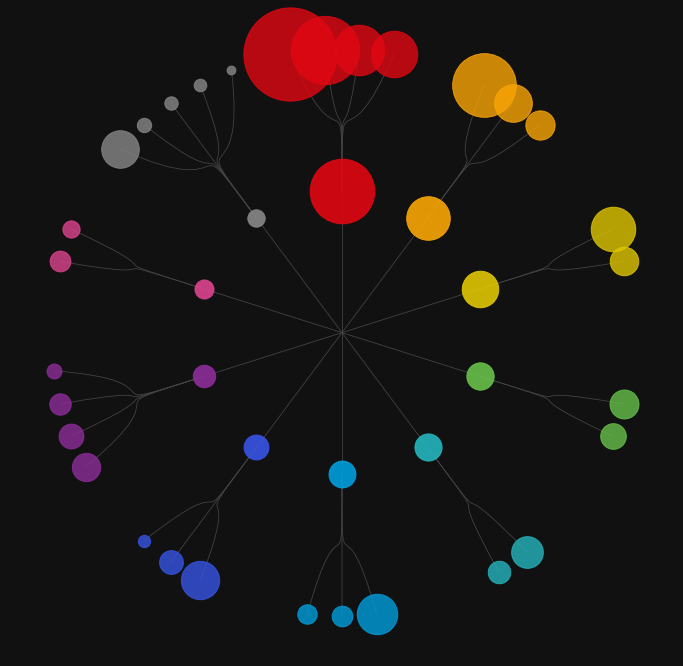

In [220]:
#Inputs  -----------------
inner_radius = 10
bezier_radius1 = inner_radius*1.9  
bezier_radius2 = inner_radius*1.1
outer_radius = inner_radius*2
num_categories = len(series)
norm = 30

#get marker sizes
category_marker_sizes = film[["category", variable+"_mean"]].drop_duplicates()[variable+"_mean"].values / norm
subcategory_counts = film[["category", "film_no"]].drop_duplicates()["film_no"].values
subcategory_marker_sizes = []
for category in film["category"].unique():
    subcategory_marker_sizes.append(film[film["category"]==category][variable].values / norm)
colors = cat_colors.values()

#get positions
x_inner, y_inner, inner_angles = calculate_positions(inner_radius, num_categories)
x_bezier1, y_bezier1, bezier_angle1 = calculate_positions(bezier_radius1, num_categories)
x_bezier2, y_bezier2, bezier_angle2 = calculate_positions(bezier_radius2, num_categories)

# Plot ----------------------------------
fig, ax = plt.subplots(figsize=(12, 12))

#plot categories in inner circle
for i, (xi, yi, ms, angle, xib1, yib1, xib2, yib2, color) in enumerate(zip(x_inner, y_inner, category_marker_sizes, inner_angles, x_bezier1, y_bezier1, x_bezier2, y_bezier2, colors)):
    ax.plot(xi, yi, 'o', markersize=ms, zorder=3, color=color, alpha=0.9)
    ax.plot([0, xi], [0, yi], '#444444', linewidth=0.8, zorder=2)  

    # Calculate subcategory positions for each inner circle element
    sub_x, sub_y, sub_angles = calculate_subcategory_positions(angle, outer_radius, subcategory_counts[i], num_categories)
    
    # Plot subcategory elements
    for sx, sy, sub_angle, ms in zip(sub_x, sub_y, sub_angles, subcategory_marker_sizes[i]):
        ax.plot(sx, sy, 'o', markersize=ms, zorder=3, color=color, alpha=0.8)

        #plot bezier curves from category to subcategory element
        indent = 2
        verts = [(xi, yi), (xib1, yib1), (xib2,yib2), (sx, sy)] 
        codes = [Path.MOVETO] + [Path.CURVE4] * 3
        path = Path(verts, codes)
        patch = patches.PathPatch(path, facecolor='none', edgecolor='#444444', linewidth=0.8, zorder=2)
        ax.add_patch(patch)

axis_offset = 3
ax.set_xlim(-outer_radius - axis_offset, outer_radius + axis_offset)
ax.set_ylim(-outer_radius - axis_offset, outer_radius + axis_offset)
ax.axis("off")

fig.set_facecolor("#111111")

#export
fig.savefig("Marvel_movies_revenue.svg")
plt.show()

In [182]:
len(series)

10

## Playground

In [ ]:
pivot = df.groupby(["intake_type_dv","animal_type_dv"])["animal_id"].count().unstack()
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values(by="total", ascending=False)
for column in pivot.columns:
    pivot.loc["total", column] = pivot[column].sum()
column_sort = pivot.loc["total"].sort_values(ascending=False).index[1:].to_list() + ["total"]
pivot.columns = column_sort
pivot

,cat,dog,bird,wild,other,rabbit,reptile,guinea pig,total
intake_type_dv,,,,,,,,,
stray,211.0,12761.0,7407.0,82.0,122.0,348.0,173.0,22.0,21126.0
wildlife,1800.0,NaN,1.0,1.0,1140.0,43.0,102.0,1386.0,4473.0
owner surrender,33.0,948.0,1343.0,74.0,60.0,128.0,28.0,1.0,2615.0
welfare seized,13.0,141.0,318.0,2.0,4.0,1.0,3.0,2.0,484.0
confiscate,6.0,57.0,310.0,13.0,2.0,4.0,6.0,1.0,399.0
return,NaN,127.0,177.0,NaN,NaN,2.0,NaN,NaN,306.0
quarantine,NaN,19.0,143.0,NaN,NaN,NaN,NaN,NaN,162.0
safe keep,NaN,16.0,65.0,NaN,17.0,NaN,32.0,NaN,130.0
other,12.0,76.0,4.0,NaN,NaN,NaN,NaN,NaN,92.0


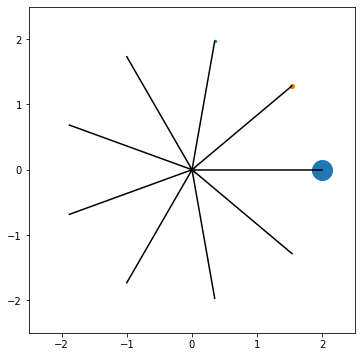

In [ ]:

#calculate positions on the circle ---------------
def calculate_positions(radius, num_elements):
    angles = np.linspace(0, 2 * np.pi, num_elements, endpoint=False)
    x_positions = radius * np.cos(angles)
    y_positions = radius * np.sin(angles)
    return x_positions, y_positions

radius = 2  
num_elements = 9  
x, y = calculate_positions(radius, num_elements)

# Normalize counts to a reasonable marker size range
counts = pivot["total"][:-1].astype(int).values
marker_sizes = (counts - counts.min()) / (counts.max() - counts.min()) * 20
 

# Plot ----------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(0, 0, 'rx')  # Center point

#plot elements
for xi, yi, ms in zip(x,y, marker_sizes):
    ax.plot(xi, yi, 'o', markersize=ms) 
    ax.plot([0, xi], [0, yi], 'k-') 



ax.set_xlim(-radius - 0.5, radius + 0.5)
ax.set_ylim(-radius - 0.5, radius + 0.5)
ax.set_aspect('equal')

plt.show()

In [33]:
df.groupby(["intake_type_dv"])["animal_id"].count()

intake_type_dv
confiscate           399
other                 92
owner surrender     2615
quarantine           162
return               306
safe keep            130
stray              21126
welfare seized       484
wildlife            4473
Name: animal_id, dtype: int64

In [25]:
df["animal_type_dv"] = df["animal_type"].str.replace("livestock", "other").str.replace("amphibian", "other")

In [32]:
df["intake_type_dv"] = df["intake_type"].str.replace("adopted animal return", "other").str.replace(
    "foster", "other").str.replace("euthenasia required", "other").str.replace("trap, neuter, return", "other")

In [12]:
df[df["primary_color"]=="tan"]

,animal_id,animal_name,animal_type,primary_color,secondary_color,sex,dob,intake_date,intake_condition,intake_type,...,outcome_date,crossing,jurisdiction,outcome_type,outcome_subtype,latitude,longitude,outcome_is_dead,was_outcome_alive,geopoint
42,A603548,NaN,dog,tan,white,Male,2014-02-08,2018-02-08,normal,stray,...,2018-02-14,"10 BLK W BORT ST, LONG BEACH, CA 90805",Long Beach,transfer,spcala,33.870346,-118.202016,False,True,"33.8703458, -118.2020155"
93,A605399,happy,dog,tan,NaN,Neutered,2007-03-27,2018-03-27,injured mild,stray,...,2018-03-31,"100 BLK CHERRY AVE, LONG BEACH, CA 90802",Long Beach,euthanasia,ill severe,33.765221,-118.167597,True,False,"33.7652208, -118.1675969"
132,A706704,NaN,dog,tan,NaN,Female,2018-09-12,2023-09-12,injured severe,stray,...,2023-09-13,"100 BLK E DEL AMO, LB 90805",Long Beach,euthanasia,at vet,33.846550,-118.193757,True,False,"33.8465498, -118.1937565"
150,A606752,NaN,dog,tan,white,Male,2017-11-26,2018-04-26,normal,stray,...,2018-05-02,"100 BLK E OSGOOD ST, LONG BEACH, CA 90805",Long Beach,transfer,spcala,33.863438,-118.193933,False,True,"33.8634376, -118.1939327"
170,A692018,snow,dog,tan,black,Neutered,2020-01-19,2023-01-19,normal,stray,...,2023-05-24,"100 BLK LONG BEACH BLVD, LB CA 90802",Long Beach,adoption,web,33.768301,-118.188740,False,True,"33.7683013, -118.1887403"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29777,A590968,*jammer,dog,tan,white,Male,2013-05-28,2017-05-28,normal,stray,...,2017-06-04,"WINDJAMMER RD / WINDWARD AVE, CERRITOS, CA 90703",Cerritos,transfer,spcala,33.877198,-118.095875,False,True,"33.8771982, -118.0958749"
29779,A603006,NaN,dog,tan,NaN,Male,2017-03-24,2018-01-24,normal,stray,...,2018-01-31,"WOODRUFF AVE / E CARSON ST, LONG BEACH, CA 90808",Long Beach,transfer,spcala,33.832336,-118.116539,False,True,"33.8323363, -118.1165386"
29780,A596730,*athena,dog,tan,white,Female,2009-09-08,2017-09-08,ill mild,stray,...,2017-09-29,"WOODRUFF AVE / E MONLACO RD, LONG BEACH, CA 90808",Long Beach,rescue,kittykatch,33.822297,-118.116472,False,True,"33.8222973, -118.1164717"
29783,A607648,*betsie,dog,tan,black,Female,2015-12-16,2018-05-16,normal,stray,...,2018-05-22,"WOODRUFF AVE / E WILLOW ST, LONG BEACH, CA 90815",Long Beach,transfer,spcala,33.803196,-118.114522,False,True,"33.803196, -118.1145217"
